# Trabalho Prático 2 — Ciência de Dados
## Inflação sobre bens de consumo: Brasil e o mundo

### Objetivo

Este notebook inicia uma análise da evolução da inflação ao consumidor, com foco na comparação do Brasil com outros países e regiões do mundo.

O indicador utilizado é **“Inflation, consumer prices (annual %)” (FP.CPI.TOTL.ZG)**, disponibilizado pelo World Bank por meio dos World Development Indicators. A base enviada foi atualizada em **13/07/2026** e contém observações anuais de 1960 a 2025.

> **Observação metodológica:** o indicador mede a variação percentual anual dos preços ao consumidor. Portanto, ele representa uma **taxa de inflação**, e não o nível absoluto de preços nem o custo de uma cesta específica de bens.

## 1. Bibliotecas

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from IPython.display import display

## 2. Carregamento dos dados

O CSV do World Bank possui linhas introdutórias antes do cabeçalho. Por isso, neste arquivo, `skiprows=4` é utilizado no dataset principal. O metadata possui cabeçalho tabular próprio e não deve receber o mesmo tratamento.

O carregamento é feito passando o conteúdo do arquivo por `StringIO`, mantendo a abordagem utilizada no trabalho anterior.

In [16]:
with open("./API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_368812.csv", "r", encoding="utf-8-sig") as file:
    inflation_csv = file.read()

with open("./Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_368812.csv", "r", encoding="utf-8-sig") as file:
    metadata_csv = file.read()

inflation_df = pd.read_csv(StringIO(inflation_csv), skiprows=4)
country_meta = pd.read_csv(StringIO(metadata_csv))

print("Dataset principal:", inflation_df.shape)
print("Metadata:", country_meta.shape)

Dataset principal: (265, 71)
Metadata: (264, 6)


## 4. Estrutura inicial

O dataset principal apresenta os anos como colunas, isto é, está no formato **wide**. As colunas de identificação são `Country Name`, `Country Code`, `Indicator Name` e `Indicator Code`.

Os anos de 1960 a 2025 serão identificados automaticamente para evitar depender de uma lista digitada manualmente.

In [17]:
year_columns = [col for col in inflation_df.columns if str(col).isdigit()]

print("Primeiro ano:", year_columns[0])
print("Último ano:", year_columns[-1])
print("Quantidade de anos:", len(year_columns))

display(inflation_df.head())

Primeiro ano: 1960
Último ano: 2025
Quantidade de anos: 66


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,4.270111,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,1.657818,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020,NaN


## 5. Normalização dos tipos

As colunas anuais serão convertidas para valores numéricos. Valores vazios do CSV são transformados em `NaN`, permitindo que o Pandas os reconheça como dados ausentes.

Não será feita imputação nesta etapa. Primeiro é necessário medir a cobertura dos dados para decidir quais anos e quais entidades podem sustentar a análise.

In [18]:
inflation_df[year_columns] = inflation_df[year_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

print("Quantidade total de valores ausentes:")
print(inflation_df[year_columns].isna().sum().sum())

display(inflation_df[["Country Name", "Country Code"] + year_columns[:5]].head())

Quantidade total de valores ausentes:
6018


,Country Name,Country Code,1960,1961,1962,1963,1964
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN


## 6. Integração com os metadados

A classificação será obtida pela coluna `Region` do metadata. Entidades com `Region` preenchida são países; entidades sem região são agregados do Banco Mundial.

Isso é particularmente importante neste estudo porque a base contém tanto países quanto agregados como **Arab World**, **High income**, **Low income** e agregados regionais. Não devemos misturá-los ao calcular médias entre países.

O código utiliza `Country Code` como chave, evitando problemas causados por diferenças de grafia nos nomes.

In [19]:
country_meta["Type"] = np.where(
    country_meta["Region"].notna(),
    "Country",
    "Aggregated"
)

metadata_columns = [
    "Country Code",
    "Region",
    "IncomeGroup",
    "Type"
]

inflation_df = inflation_df.merge(
    country_meta[metadata_columns],
    on="Country Code",
    how="left"
)

print(inflation_df["Type"].value_counts(dropna=False))
display(inflation_df[[
    "Country Name", "Country Code", "Region", "IncomeGroup", "Type"
]].head(10))

Type
Country       217
Aggregated     47
NaN             1
Name: count, dtype: int64


,Country Name,Country Code,Region,IncomeGroup,Type
0,Aruba,ABW,Latin America & Caribbean,High income,Country
1,Africa Eastern and Southern,AFE,NaN,NaN,Aggregated
2,Afghanistan,AFG,Middle East & North Africa,Low income,Country
3,Africa Western and Central,AFW,NaN,NaN,Aggregated
4,Angola,AGO,Sub-Saharan Africa,Lower middle income,Country
5,Albania,ALB,Europe & Central Asia,Upper middle income,Country
6,Andorra,AND,Europe & Central Asia,High income,Country
7,Arab World,ARB,NaN,NaN,Aggregated
8,United Arab Emirates,ARE,Middle East & North Africa,High income,Country
9,Argentina,ARG,Latin America & Caribbean,Upper middle income,Country


## 7. Verificação de inconsistências

Neste dataset
Nesta etapa, o foco será detectar valores não numéricos e verificar a existência de valores extremos. Valores muito altos de inflação podem representar episódios econômicos reais e, por isso, não devem ser removidos apenas por serem grandes.

In [20]:
invalid_count = inflation_df[year_columns].isna().sum().sum()

print("Valores ausentes:", invalid_count)
print("Menor taxa observada:", inflation_df[year_columns].min().min())
print("Maior taxa observada:", inflation_df[year_columns].max().max())

display(
    inflation_df[year_columns]
    .stack()
    .describe()
)

Valores ausentes: 6018
Menor taxa observada: -17.6404240920371
Maior taxa observada: 23773.1317741016


count    11472.000000
mean        19.307981
std        282.592631
min        -17.640424
25%          2.372799
50%          4.775528
75%          9.524845
max      23773.131774
dtype: float64

## 8. Separação entre países e regiões agregadas

Serão mantidas duas visões da base:

- `inflation_countries`: somente países, destinada às comparações entre países, rankings e cálculo de estatísticas por região.
- `inflation_aggregates`: Uniões de países agrupados por locaglização geográfica ou econômica fornecidos pelo Banco Mundial, que podem ser úteis para comparação e validação, mas não serão misturados às estatísticas calculadas a partir dos países.

A base original `inflation_df` continua preservada.

In [21]:
inflation_countries = inflation_df[
    inflation_df["Type"] == "Country"
].copy()

inflation_aggregates = inflation_df[
    inflation_df["Type"] == "Aggregated"
].copy()

print("Países:", len(inflation_countries))
print("Agregados:", len(inflation_aggregates))

Países: 217
Agregados: 47


## 9. Cobertura dos dados por ano

Antes de escolher o período de análise, será calculada a proporção de países com valores válidos em cada ano.

Esse diagnóstico permitirá definir um critério objetivo para o período analisado, em vez de escolher arbitrariamente um ano inicial. A imputação de valores faltantes será tratada somente depois dessa decisão.

In [22]:
coverage = inflation_countries[year_columns].notna().mean()

coverage_df = pd.DataFrame({
    "Year": coverage.index.astype(int),
    "Coverage": coverage.values,
    "Coverage (%)": coverage.values * 100
})

display(coverage_df.head())
display(coverage_df.tail())

,Year,Coverage,Coverage (%)
0,1960,0.290323,29.032258
1,1961,0.299539,29.953917
2,1962,0.308756,30.875576
3,1963,0.308756,30.875576
4,1964,0.331797,33.179724


,Year,Coverage,Coverage (%)
61,2021,0.820276,82.027650
62,2022,0.820276,82.027650
63,2023,0.811060,81.105991
64,2024,0.801843,80.184332
65,2025,0.760369,76.036866


## 10. Definição do período de análise

O gráfico abaixo permite identificar visualmente em quais períodos a base apresenta maior disponibilidade de dados. A partir dele poderá ser estabelecido um limiar mínimo de cobertura para a análise principal. Para o estudo, foram considerados válidos anos que possuíam cobertura maior que 60%

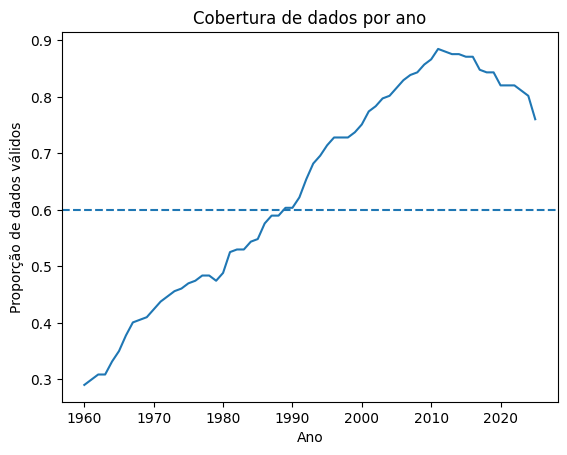

In [23]:
# Definir mínimo de dados para ser considerado válido

f_min_data = inflation_countries[year_columns].notna().mean()
valid_years = f_min_data[f_min_data >= 0.60].index

f_min_data.plot()

plt.axhline(0.60, linestyle='--')
plt.title("Cobertura de dados por ano")
plt.ylabel("Proporção de dados válidos")
plt.xlabel("Ano")

plt.show()

In [24]:
# Filtrar apenas os anos válidos
inflation_countries_filtered = inflation_countries[
    ["Country Name", "Country Code", "Region", "IncomeGroup"] + list(valid_years)
]

print("Anos válidos:", valid_years)

Anos válidos: Index(['1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='str')


In [25]:
inflation_df_long = inflation_countries_filtered.melt(
    id_vars=["Country Name", "Country Code", "Region", "IncomeGroup"],
    value_vars=valid_years,
    var_name="Year",
    value_name="Inflation Rate"
)

inflation_df_long["Year"] = inflation_df_long["Year"].astype(int)
display(inflation_df_long.head())

,Country Name,Country Code,Region,IncomeGroup,Year,Inflation Rate
0,Aruba,ABW,Latin America & Caribbean,High income,1989,3.991628
1,Afghanistan,AFG,Middle East & North Africa,Low income,1989,NaN
2,Angola,AGO,Sub-Saharan Africa,Lower middle income,1989,NaN
3,Albania,ALB,Europe & Central Asia,Upper middle income,1989,NaN
4,Andorra,AND,Europe & Central Asia,High income,1989,NaN


In [26]:
# Quantidade de dados faltantes
missing_data = inflation_df_long["Inflation Rate"].isna().sum()

print(f"Quantidade de dados faltantes: {missing_data}")

Quantidade de dados faltantes: 1718


## Interpolação de dados e preenchimento dos faltantes

In [ ]:
#Interpolação
inflation_df_long = inflation_df_long.sort_values(["Country Code", "Year"])

inflation_df_long["Inflation Rate"] = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform(
    lambda x: x.interpolate(method="linear", limit=3, limit_direction="both")
)

#Substituição pela média do país caso ainda haja lacunas:
inflation_country_mean = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform("mean")

inflation_df_long["Inflation Rate"] = inflation_df_long["Inflation Rate"].fillna(inflation_country_mean)

# Drop, caso ainda haja lacunas:
inflation_df_long = inflation_df_long.dropna(subset=["Inflation Rate"])

print("Dados ainda faltantes no período analisado:")
print(inflation_df_long["Inflation Rate"].isna().sum())
print("\n")

# Resumo estatístico da inflação por região do mundo
inflation_df_long.groupby("Region")["Inflation Rate"].describe()

Dados ainda faltantes no período analisado:
0
    Country Name Country Code                     Region  IncomeGroup  Year  \
0          Aruba          ABW  Latin America & Caribbean  High income  1989   
217        Aruba          ABW  Latin America & Caribbean  High income  1990   
434        Aruba          ABW  Latin America & Caribbean  High income  1991   
651        Aruba          ABW  Latin America & Caribbean  High income  1992   
868        Aruba          ABW  Latin America & Caribbean  High income  1993   

     Inflation Rate  
0          3.991628  
217        5.836688  
434        5.555556  
651        3.873375  
868        5.215560  


,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
East Asia & Pacific,1147.0,5.541729,17.452795,-4.009434,1.048255,2.833400,5.675000,268.150489
Europe & Central Asia,1813.0,54.325558,322.960401,-10.630097,1.801170,3.289706,8.796388,4734.914347
Latin America & Caribbean,1332.0,28.121294,256.784438,-7.113768,1.934190,4.207726,8.809569,7481.663611
Middle East & North Africa,851.0,9.664982,27.641137,-16.117326,1.685408,3.625741,9.284938,448.500000
North America,74.0,2.527192,1.453792,-0.355546,1.621468,2.263310,2.951124,8.002800
South Asia,222.0,6.865291,5.022737,-4.763860,3.839101,6.277942,8.909331,49.721102
Sub-Saharan Africa,1702.0,42.894192,606.288480,-16.859691,2.840016,6.427553,12.524126,23773.131774


## 11. Próximas etapas
1. Comparar o Brasil com:
   - média dos países;
   - regiões do Banco Mundial;
   - grupos de renda;
   - países selecionados.
2. Construir séries temporais e indicadores específicos para o Brasil.
3. Investigar episódios de inflação elevada e sua duração.
4. Estruturar as visualizações finais para o dashboard.